# hls4snn

This is a simple notebook that shows how to use hls4ml for SNNs, with neurobench also.

## imports

Make sure to run:

`
source /tools/Xilinx/Vitis/2024.1/settings64.sh
`

`
source /tools/Xilinx/Vivado/2024.1/settings64.sh
`

in the terminal before launching the notebook.

In [20]:
import os
import sys
import argparse
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import hls4ml
import hls4ml.utils.torch
print(hls4ml.__file__)
import snntorch as snn

import neurobench
from neurobench.models import TorchModel, SNNTorchModel
from neurobench.benchmarks import Benchmark
from neurobench.metrics.static import (
    Footprint,
    ConnectionSparsity,
)
from neurobench.metrics.workload import (
    ClassificationAccuracy,
    ActivationSparsity,
    SynapticOperations,
)

/home/b/Physics/hls4ml/hls4ml/__init__.py


## data

creating a simple 2D dataset for testing the SNN

In [2]:
def make_synthetic_stream_data(n_samples: int, timesteps: int, seed: int = 1234):
    rng = np.random.default_rng(seed)
    x = rng.normal(loc=0.0, scale=1.0, size=(n_samples, timesteps, 2)).astype(np.float32)
    score = np.sum(0.9 * x[:, :, 0] - 0.6 * x[:, :, 1], axis=1)
    y = (score > 0.0).astype(np.int64)
    return torch.from_numpy(x), torch.from_numpy(y)

In [3]:
def make_simple_gaussian_streams_2d(
    n_samples: int,
    timesteps: int,
    seed: int = 1234,
    mean_shift: float = 1.0,
    std: float = 1.0,
):
    rng = np.random.default_rng(seed)
    y = rng.integers(0, 2, size=n_samples)
    x = rng.normal(loc=0.0, scale=std, size=(n_samples, timesteps, 2)).astype(np.float32)

    # Shift only the first channel by class
    x[y == 0, :, 0] -= mean_shift
    x[y == 1, :, 0] += mean_shift
    return torch.from_numpy(x), torch.from_numpy(y.astype(np.int64))

In [4]:
def plot_2d_streams(x, y, max_per_class=50):
    """
    x: torch.Tensor or np.ndarray of shape (n_samples, timesteps, 2)
    y: torch.Tensor or np.ndarray of shape (n_samples,)
    """
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    if hasattr(y, "detach"):
        y = y.detach().cpu().numpy()

    x0 = x[y == 0]
    x1 = x[y == 1]

    # Optionally limit how many raw streams to draw
    x0_plot = x0[:max_per_class]
    x1_plot = x1[:max_per_class]

    t = np.arange(x.shape[1])

    # LaTeX-like font styling
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
        "font.size": 12,
    })

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for d, ax in enumerate(axes):
        # Raw streams
        for seq in x0_plot:
            ax.plot(t, seq[:, d], alpha=0.10, linewidth=1.0)
        for seq in x1_plot:
            ax.plot(t, seq[:, d], alpha=0.10, linewidth=1.0)

        # One visible line per class for legend
        ax.plot(t, x0_plot[0, :, d], alpha=0.5, linewidth=1.2, label="Class 0 streams", color='green')
        ax.plot(t, x1_plot[0, :, d], alpha=0.5, linewidth=1.2, label="Class 1 streams", color='red')

        # Class means
        ax.plot(t, x0[:, :, d].mean(axis=0), linewidth=3.0, label="Class 0 mean", color='green')
        ax.plot(t, x1[:, :, d].mean(axis=0), linewidth=3.0, label="Class 1 mean", color='red')

        ax.set_title(rf"Dimension ${d}$")
        ax.set_ylabel(r"Value")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False, ncol=2)

    axes[-1].set_xlabel(r"Timestep $t$")
    fig.suptitle(r"2D stream data by input dimension", fontsize=16)
    plt.tight_layout()
    plt.show()

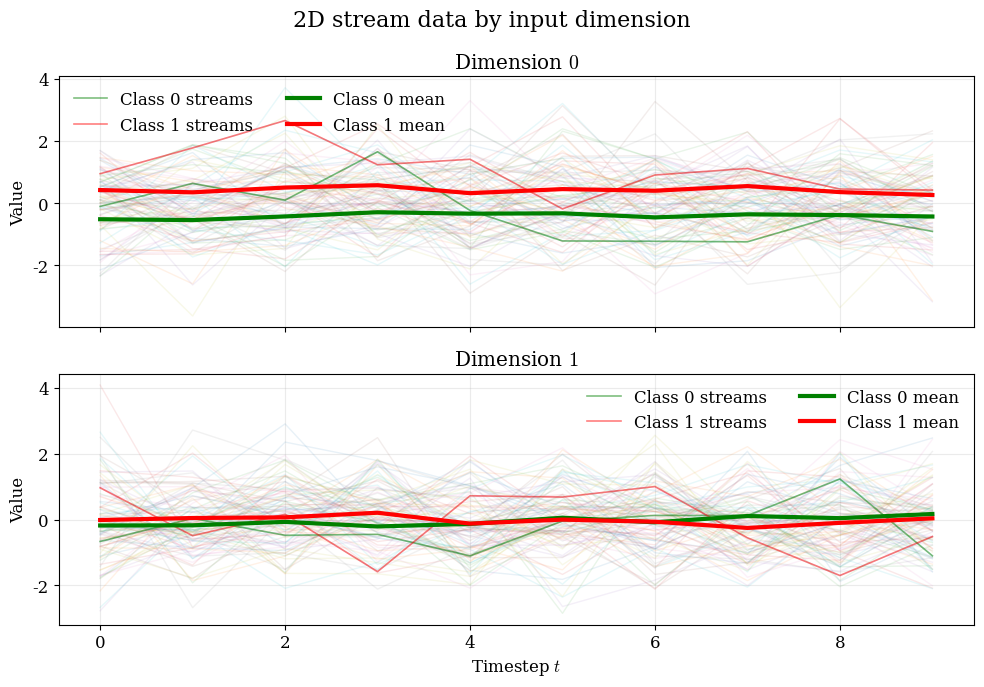

In [5]:
x, y = make_simple_gaussian_streams_2d(n_samples=200, timesteps=10, mean_shift=0.4)
plot_2d_streams(x, y)

## neural nets

defining the SNN here where the forward pass loops through all timesteps in the data

In [43]:
class SNN_LIF(nn.Module):
    """
    SNN model using snnTorch Leaky neuron in IF-equivalent mode (beta=1).
    This is the one we use to optimise the weights
    """

    def __init__(self, hidden: int = 16, threshold: float = 1.0, beta: float = 1.0):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.if1 = snn.Leaky(beta=beta, threshold=threshold, reset_mechanism='subtract')
        self.fc2 = nn.Linear(hidden, 2)

    def forward(self, x_seq: torch.Tensor) -> torch.Tensor:
        # x_seq: [B, T, 2]
        bsz, _, _ = x_seq.shape
        mem = torch.zeros(bsz, self.fc1.out_features, device=x_seq.device, dtype=x_seq.dtype)
        out = torch.zeros(bsz, 2, device=x_seq.device, dtype=x_seq.dtype)

        for t in range(x_seq.shape[1]):
            cur1 = self.fc1(x_seq[:, t, :])
            spk1, mem = self.if1(cur1, mem)
            out = out + self.fc2(spk1)
        return out

making a single-step SNN here, because this is the version that will be used with hls4ml

In [44]:
class SNN_LIF_step(nn.Module):
    """
    Single-timestep model for hls4ml conversion: 2 -> Dense(16) -> IF -> Dense(2).
    This is the one we use to put through HLS in stream mode
    """

    def __init__(self, hidden: int = 16, threshold: float = 1.0, beta: float = 1.0):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.if1 = snn.Leaky(beta=beta, threshold=threshold, reset_mechanism='subtract')
        self.fc2 = nn.Linear(hidden, 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x, _ = self.if1(x)
        x = self.fc2(x)
        # neurobench requires 2D output from the single step NN
        return x, None

## train function

very simple train function for testing purposes

In [45]:
def train_snn(
    model,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    epochs: int = 5,
    batch_size: int = 64,
    lr: float = 5e-3,
):
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    n_samples = x_train.shape[0]
    for epoch in range(epochs):
        perm = torch.randperm(n_samples)
        epoch_loss = 0.0
        correct = 0

        for start in range(0, n_samples, batch_size):
            idx = perm[start : start + batch_size]
            xb = x_train[idx]
            yb = y_train[idx]

            logits = model.forward(xb)
            loss = criterion(logits, yb)

            optim.zero_grad()
            loss.backward()
            optim.step()

            epoch_loss += float(loss.item()) * xb.shape[0]
            correct += int((logits.argmax(dim=1) == yb).sum().item())

        print(
            f'Epoch {epoch + 1:02d}/{epochs}: '
            f'loss={epoch_loss / n_samples:.4f}, acc={correct / n_samples:.4f}'
        )

## train the net

train the SNN model

In [46]:
train_model = SNN_LIF(hidden=16, beta=0.9)
train_snn(
    train_model,
    x,
    y,
    epochs=40,
    batch_size=256,
)

Epoch 01/40: loss=1.6508, acc=0.4950
Epoch 02/40: loss=1.4839, acc=0.4950
Epoch 03/40: loss=1.3144, acc=0.4950
Epoch 04/40: loss=1.1773, acc=0.4950
Epoch 05/40: loss=1.0510, acc=0.4950
Epoch 06/40: loss=0.9358, acc=0.4950
Epoch 07/40: loss=0.8379, acc=0.4950
Epoch 08/40: loss=0.7687, acc=0.5000
Epoch 09/40: loss=0.7271, acc=0.5000
Epoch 10/40: loss=0.6972, acc=0.5400
Epoch 11/40: loss=0.6772, acc=0.5500
Epoch 12/40: loss=0.6613, acc=0.6100
Epoch 13/40: loss=0.6407, acc=0.6300
Epoch 14/40: loss=0.6061, acc=0.6700
Epoch 15/40: loss=0.5802, acc=0.6800
Epoch 16/40: loss=0.5514, acc=0.7400
Epoch 17/40: loss=0.5107, acc=0.8000
Epoch 18/40: loss=0.4786, acc=0.8450
Epoch 19/40: loss=0.4461, acc=0.8750
Epoch 20/40: loss=0.4129, acc=0.9050
Epoch 21/40: loss=0.3928, acc=0.9100
Epoch 22/40: loss=0.3692, acc=0.9200
Epoch 23/40: loss=0.3514, acc=0.9200
Epoch 24/40: loss=0.3359, acc=0.9150
Epoch 25/40: loss=0.3234, acc=0.9200
Epoch 26/40: loss=0.3129, acc=0.9200
Epoch 27/40: loss=0.3003, acc=0.9250
E

copy the weights to the single-step network for hls conversion

In [47]:
single_step_model = SNN_LIF_step(hidden=16, beta=0.9, threshold=1.0)
single_step_model.fc1.load_state_dict(train_model.fc1.state_dict())
single_step_model.fc2.load_state_dict(train_model.fc2.state_dict())
single_step_model.eval()

SNN_LIF_step(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (if1): Leaky()
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)

## run hls4ml

now we run the hls4ml package

In [60]:
rname = 'snn_test_lif'
output_dir = Path(rname)
backend = 'Vitis'

# optional load model weights instead
#torch.save(single_step_model.state_dict(), output_dir / "model_weights.pt")
#state_dict = torch.load(output_dir / "model_weights.pt")
#single_step_model.load_state_dict(state_dict)
#single_step_model.eval()

# create savedir
output_dir.mkdir(parents=True, exist_ok=True)

# set variable for precision
q4 = 'ap_fixed<4,2>'

# build the initial per-layer config
hls_config = hls4ml.utils.config_from_pytorch_model(
    single_step_model,     # model we are converting
    input_shape=(2,),      # one timestep input shape
    granularity='name',    # create entries per layer name
    backend=backend,       # use specified backend, vitis/vivado
    default_precision=q4,  # default weight precision
)

# set reuse factor
hls_config['Model']['ReuseFactor'] = 1

# quantizing all model variables
hls_config['Model']['Precision']['default'] = q4
for _, layer_cfg in hls_config.get('LayerName', {}).items():
    prec = layer_cfg.setdefault('Precision', {})
    prec['result'] = q4
    prec['accum'] = q4
    prec['weight'] = q4
    prec['bias'] = q4

# convert to hls4ml Model Graph
hls_model = hls4ml.converters.convert_from_pytorch_model(
    single_step_model,             # model we are converting
    output_dir=str(output_dir),    # where we save the model
    project_name=rname,            # project name
    backend=backend,               # vitis/vivado
    io_type='io_stream',           # io_stream or io_parallel
    #io_type='io_parallel',        
    hls_config=hls_config,         # the config from above
    part="xczu7ev-ffvc1156-2-e",   # set your FPGA part
    clock_period=5,                # clock period in nanoseconds
    clock_uncertainty="27%",       # clock uncertainty
)
# writes c++/headers/tcl/project files to disk
hls_model.write()

# check it all exists
hls_cpp = output_dir / 'firmware' / Path( rname + '.cpp' )
if not hls_cpp.exists():
    raise RuntimeError(f'Expected generated HLS source missing: {hls_cpp}')

# print result
print(f'Generated HLS project at: {output_dir}')
print(f'Generated top file: {hls_cpp}')

# build and get vitis report
rep = hls_model.build(
    reset=True,
    csim=True,
    synth=True,
    cosim=True,
    validation=True,
    export=True,
    vsynth=True,
)
rep

Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 2]]
Layer name: if1, layer type: LIFNeuron, input shape: [[None, 16]]
Layer name: fc2, layer type: Dense, input shape: [[None, 16]]
Generated HLS project at: snn_test_lif
Generated top file: snn_test_lif/firmware/snn_test_lif.cpp

****** vitis-run v2024.1 (64-bit)
  **** SW Build 5074859 on 2024-05-20-23:21:20
  **** Start of session at: Mon Apr 27 10:37:51 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/b/Physics/hls4ml/snn_test_lif/build_prj.tcl -work_dir /home/b/Physics/hls4ml/snn_test_lif

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2

{'CSimResults': [['-0.25', '-0.25'],
  ['-0.25', '-0.25'],
  ['-0.25', '-1'],
  ['-0.25', '-0.75'],
  ['-0.25', '-0.25']],
 'CosimResults': [['-0.25', '-0.25'],
  ['-0.25', '-0.25'],
  ['-0.25', '-1'],
  ['-0.25', '-0.75'],
  ['-0.25', '-0.25']],
 'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.524',
  'BestLatency': '6',
  'WorstLatency': '6',
  'IntervalMin': '3',
  'IntervalMax': '3',
  'FF': '450',
  'LUT': '1744',
  'BRAM_18K': '0',
  'DSP': '0',
  'URAM': '0',
  'AvailableBRAM_18K': '624',
  'AvailableDSP': '1728',
  'AvailableFF': '460800',
  'AvailableLUT': '230400',
  'AvailableURAM': '96'},
 'VivadoSynthReport': {'LUT': '238',
  'FF': '282',
  'BRAM_18K': '0',
  'URAM': '0',
  'DSP48E': '0'},
 'CosimReport': {'RTL': 'Verilog',
  'Status': 'Pass',
  'LatencyMin': 8,
  'LatencyMax': 10,
  'IntervalMin': 2,
  'IntervalMax': 4,
  'LatencyAvg': 8.8,
  'IntervalAvg': 2.75}}

## run neurobench

set up the model for neurobench

In [61]:
test_loader = DataLoader(
    TensorDataset(x.float(), y.long()),
    batch_size=64,
    shuffle=False,
)

single_step_model.eval()

nb_model = SNNTorchModel(single_step_model)

define preprocessing, postprocessing, and metrics for neurobench to track

In [62]:
class ArgmaxLogits:
    def __call__(self, preds):
        return preds.sum(dim=1).argmax(dim=1)

preprocessors = []
postprocessors = [ArgmaxLogits()]

static_metrics = [
    Footprint,
    ConnectionSparsity,
]

workload_metrics = [
    ClassificationAccuracy,
    ActivationSparsity,
    SynapticOperations,
]

run the benchmark

In [63]:
rname = 'snn_test_lif'
output_dir = Path(rname)

benchmark = Benchmark(
    nb_model,
    test_loader,
    preprocessors,
    postprocessors,
    [static_metrics, workload_metrics],
)

device = "cuda" if torch.cuda.is_available() else "cpu"

results = benchmark.run(device=device)
print(results)

benchmark.save_benchmark_results(output_dir / "neurobench_results", file_format="json")

Running benchmark


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 105.50it/s]

{'Footprint': 860, 'ConnectionSparsity': 0.0, 'ClassificationAccuracy': 0.93, 'ActivationSparsity': 0.84065625, 'SynapticOperations': {'Effective_MACs': 320.0, 'Effective_ACs': 50.99, 'Dense': 640.0}}
Results saved to snn_test_lif/neurobench_results.json
